# Bath_dMFA_2026 Software 4

## Materials in the vehicle fleet of the EUR20 countries

In this exercise, we estimate the material content of the entire fleet (current in-use stock is the future recycling potential), the material demand for new vehicles, the material outflow for recycling, and the potential for a circular economy of materials in the vehicle sector.

This calculation exercise covers calculations on the material stocks and flows, the recycling potential, and the recycled content for passenger vehicles in the EUR20 countries
It is a follow-up to Software workbooks Bath_dMFA_2026_Software 1-3.

The data workbook *Bath_dMFA_2026_Software_Data.xlsx* contains a number of parameters for the calculation.

The core of the multi-material cycle model is the dynamic fleet model, which is a description of the current and future vehicle fleet (or stock) *S* by year *t* and age-cohort (or year of registration) *c*: *S(t,c)*. 

The future stock was determined from service demand (pkm) and intensity of use paramters, and broken down into drive technologies and age-cohorts with the inflow-driven and stock-driven model.

### Task 1: Load the vehicle inflow, stock, and outflow data from the previous exercise and convert the vehicle flows to material flows!

In [1]:
# First, import required libraries:
import pandas as pd   # dataframe library, used for fast import/export from/to excel and for organizing the data.
import numpy as np    # math library
import matplotlib.pyplot as plt  # plotting library
import pickle

In [2]:
with open('Bath_dMFA_2026_Software_3_Results.pkl', 'rb') as f:
    DynFleetResults = pickle.load(f) # deserialize using load()
print(DynFleetResults['I_Veh_cT' ].shape)
print(DynFleetResults['S_Veh_tcT'].shape)
print(DynFleetResults['O_Veh_tcT'].shape)

(71, 2)
(71, 71, 2)
(71, 71, 2)


In [3]:
# Material composition of vehicles
MC = pd.read_excel('Bath_dMFA_2026_Software_Data.xlsx', sheet_name='Material_intensity', index_col=0).values
print(MC.shape) # ten material (rows) and two drive technologies (columns), applies to all age-cohorts

(10, 2)


In [4]:
# End-of-life recovery rates of materials
EoLRR = pd.read_excel('Bath_dMFA_2026_Software_Data.xlsx', sheet_name='Recovery_rates', index_col=0).values / 100 # convert to %
print(EoLRR.shape) # ten material (rows) and two Scenarios (columns), applies to all age-cohorts

(10, 2)


We use the np.einsum command to convert vehicles to material flows, using the material composition table. At the same time, we sum up over all age-cohorts and drive technologies, as the research questions below only require us to trace the total material by material type.

Here, the material composition data have the dimensions material *m* by drive technology *T*, and to keep things simple, they apply to all age-cohorts (years of production).
The calculations are as follows, with MC(mT) indicating the material composition of the vehicles:

$$ S(t,m) = \sum_{c,T} MC(m,T) \cdot S(t,c,T) $$

$$ I(t,m) = \sum_{T} MC(m,T) \cdot I(t,T) $$

$$ O(t,m) = \sum_{c,T} MC(m,T) \cdot O(t,c,T) $$

In [5]:
I_tm     = np.einsum('tT,mT->tm', DynFleetResults['I_Veh_cT' ],MC) / 1e9  # convert from kg/yr to Mt/yr
print(I_tm.shape)
S_tm     = np.einsum('tcT,mT->tm',DynFleetResults['S_Veh_tcT'],MC) / 1e9  # convert from kg to Mt
print(S_tm.shape)
O_tm     = np.einsum('tcT,mT->tm',DynFleetResults['O_Veh_tcT'],MC) / 1e9  # convert from kg/yr to Mt/yr
print(O_tm.shape)

(71, 10)
(71, 10)
(71, 10)


### Task 2: Inspect the time series of steel, aluminium, copper, and plastics in the vehicle fleet (stock), the materials in the inflow of new vehicles into the stock, and the materials in the outflow of old vehicles from the stock!

Plot the data in different graphs: one for the stock, and two for inflow and outflow of materials, or a combined one with inflow and outflow data.

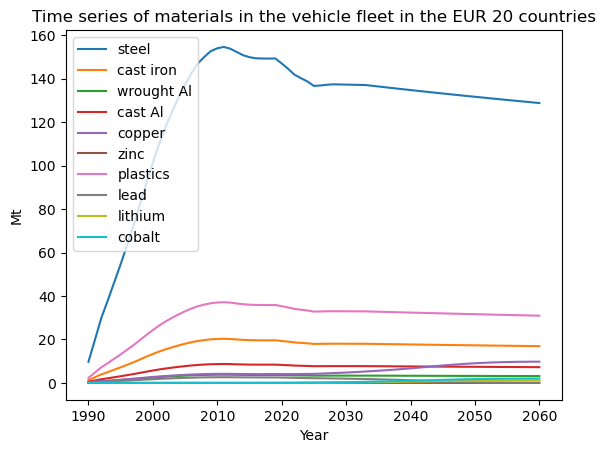

In [6]:
plt.plot(np.arange(1990,2061,1),S_tm) # plot with given x-axis values, generated with the np.arange command
plt.title('Time series of materials in the vehicle fleet in the EUR 20 countries')
plt.ylabel('Mt')
plt.xlabel('Year')
plt.legend(['steel','cast iron','wrought Al','cast Al','copper','zinc','plastics','lead','lithium','cobalt'])
plt.savefig('Materials_Fleet.png', dpi = 300) # save figure with the modifications made above.

That looks good for the bulkier materials but the technology materials can hardly be identified. Let's add a log scale:

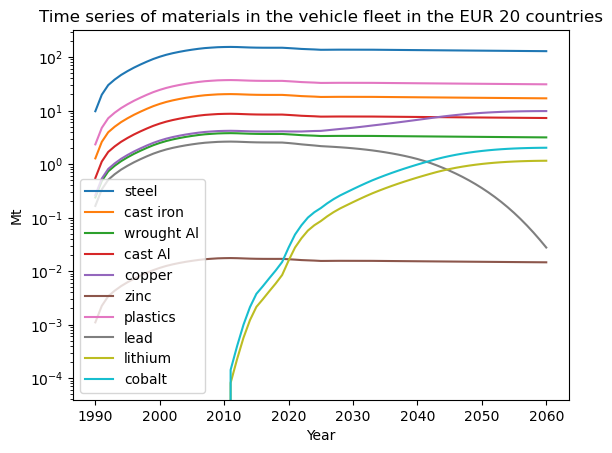

In [7]:
plt.plot(np.arange(1990,2061,1),S_tm) # plot with given x-axis values, generated with the np.arange command
plt.yscale('log')
plt.title('Time series of materials in the vehicle fleet in the EUR 20 countries')
plt.ylabel('Mt')
plt.xlabel('Year')
plt.legend(['steel','cast iron','wrought Al','cast Al','copper','zinc','plastics','lead','lithium','cobalt'])
plt.savefig('Materials_Fleet.png', dpi = 300) # save figure with the modifications made above.

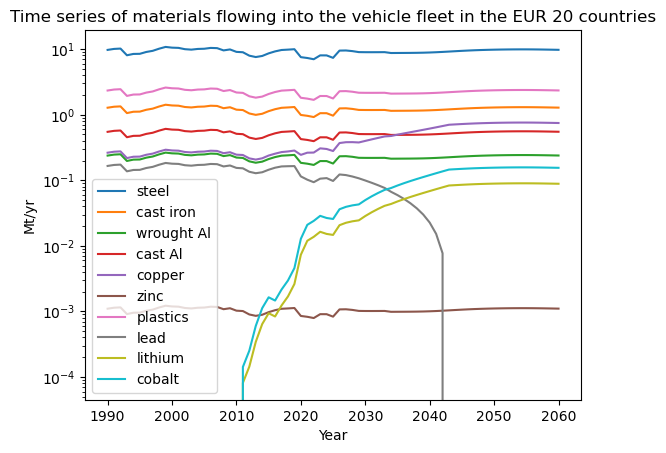

In [8]:
plt.plot(np.arange(1990,2061,1),I_tm) # plot with given x-axis values, generated with the np.arange command
plt.yscale('log')
plt.title('Time series of materials flowing into the vehicle fleet in the EUR 20 countries')
plt.ylabel('Mt/yr')
plt.xlabel('Year')
plt.legend(['steel','cast iron','wrought Al','cast Al','copper','zinc','plastics','lead','lithium','cobalt'])
plt.savefig('Materials_Inflow.png', dpi = 300) # save figure with the modifications made above.

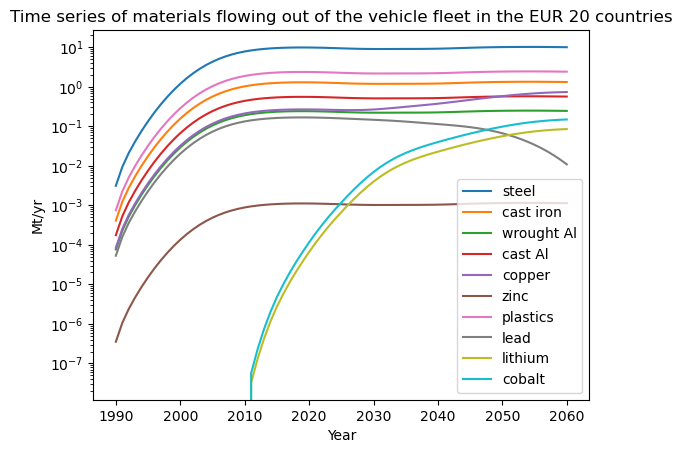

In [9]:
plt.plot(np.arange(1990,2061,1),O_tm) # plot with given x-axis values, generated with the np.arange command
plt.yscale('log')
plt.title('Time series of materials flowing out of the vehicle fleet in the EUR 20 countries')
plt.ylabel('Mt/yr')
plt.xlabel('Year')
plt.legend(['steel','cast iron','wrought Al','cast Al','copper','zinc','plastics','lead','lithium','cobalt'])
plt.savefig('Materials_Outflow.png', dpi = 300) # save figure with the modifications made above.

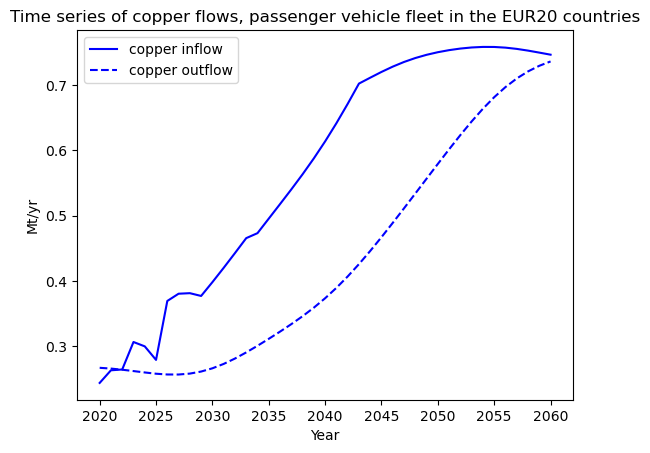

In [10]:
# Alternative: Combine inflow and outflow, here for copper only, which has an interesting development:
plt.plot(np.arange(2020,2061,1),I_tm[30::,4], linestyle = '-',  color = 'b') # plot with given x-axis values, generated with the np.arange command
plt.plot(np.arange(2020,2061,1),O_tm[30::,4], linestyle = '--', color = 'b')
plt.title('Time series of copper flows, passenger vehicle fleet in the EUR20 countries')
plt.ylabel('Mt/yr')
plt.xlabel('Year')
plt.legend(['copper inflow','copper outflow'])
plt.savefig('Copper_Flows.png', dpi = 300) # save figure with the modifications made above.

The material stocks and flows of steel are the largest by far, since steel is the main material of vehicles.
All flows steadily increase due to the increasing population.

The flows are roughly 15 times smaller than the stock, which reflects the average vehicle lifetime and the moderate increase of the fleet.

Due to the transition to BEVs modelled in the scenario, the annual inflow of copper in new vehicles will roughly triple over the  coming years, from presently about 300 kilotons to around 750 kilotons per year.

As a consequence, the outflow of copper will increase, too, with a delay of about 15 years, the average vehicle lifetime.
The curve of copper outflow is smoother than the inflow curve. This is because for the inflow, some abrupt changes in the BEV vehicle uptake are visible (a typcial result of stock-driven models), while the vehicle lifetime is not exactly 15 years but follows a distribution, with some vehicles leaving earlier and some later than 15 years, which lead to a smooth outflow curve.

### Task 3: With the given end-of-life recycling rates (Excel data workbook), how much of the material for the new vehicles could be sourced from old vehicles? How large would the 'recycled content' be in that case?

Calculate and interpret the result!

We calculate the available secondary (recycled) material, *FRec(t,m)*, by multiplying the end-of-life recovery rate by material, *EoLRR(m,S)*, to the outflow. Here, *S* is the scenario dimension for alternative futures.

$$ FRec(t,m,S) = EoLRR(m,S) \cdot O(t,m) $$


In [11]:
FRec = np.einsum('mS,tm->tmS',EoLRR,O_tm)

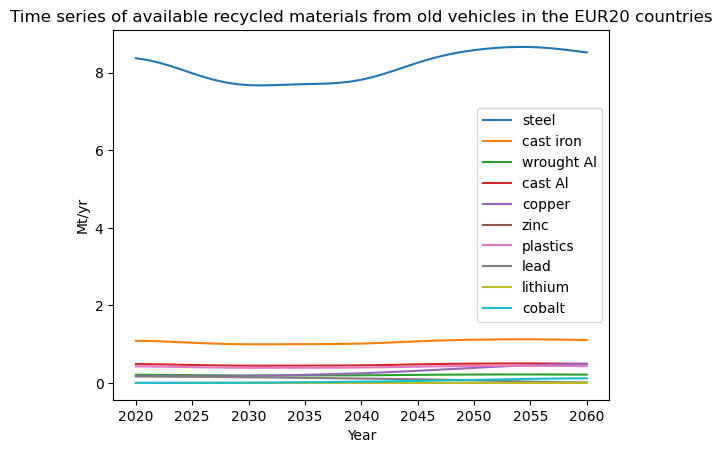

In [12]:
# Note: EoL_RR comes with two scenarios. Here, we take the first one (current situation):
plt.plot(np.arange(2020,2061,1),FRec[30::,:,0]) 
plt.title('Time series of available recycled materials from old vehicles in the EUR20 countries')
plt.ylabel('Mt/yr')
plt.xlabel('Year')
plt.legend(['steel','cast iron','wrought Al','cast Al','copper','zinc','plastics','lead','lithium','cobalt'])
plt.savefig('Materials_Recycling.png', dpi = 300) # save figure with the modifications made above.

To derive the recycled content, we assume a scenario where all secondary material sourced from end-of-life vehicles is recycled back into new vehicles. In such a situtation, the recycled content *RC(t,m)*, or the share of secondary in total material consumption, is given by the ratio of recycled material and total material:

$$ RC(t,m) = FRec(t,m) / I(t,m) $$

In [13]:
RC_base = FRec[:,:,0] / I_tm * 100
# Note: EoL_RR comes with two scenarios. Here, we take the first one (current situation).
# Note: Unit converted to %.
# Note: Warnings are issued because the element-wise division of the two tables above leads to several x/0 or 0/0 values.



C:\Users\Stefan Pauliuk\AppData\Local\Temp\ipykernel_17112\1652960131.py:1: RuntimeWarning: divide by zero encountered in divide
  RC_base = FRec[:,:,0] / I_tm * 100
C:\Users\Stefan Pauliuk\AppData\Local\Temp\ipykernel_17112\1652960131.py:1: RuntimeWarning: invalid value encountered in divide
  RC_base = FRec[:,:,0] / I_tm * 100


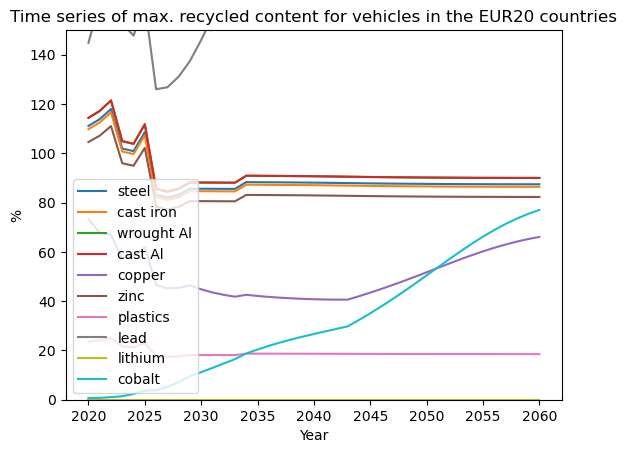

In [14]:
# The recycled content cannot be larger than 100%. If more secondary material is present, the excess material is exported to other sectors instead.
plt.plot(np.arange(2020,2061,1),RC_base[30::,:]) 
plt.title('Time series of max. recycled content for vehicles in the EUR20 countries')
plt.ylabel('%')
plt.xlabel('Year')
plt.gca().set_ylim(bottom=0) # set lower y boundary to 0
plt.gca().set_ylim(top=150) # set upper y boundary to 150 to see excess scrap supply in this sector.
plt.legend(['steel','cast iron','wrought Al','cast Al','copper','zinc','plastics','lead','lithium','cobalt'])
plt.savefig('Materials_Recycled_Content_Base.png', dpi = 300) # save figure with the modifications made above.

In the standard recycling scenario, the recycled content can be quite high, despite the imperfect recycling (recovery and remelting losses) and the growing stock of BEVs. Up to 85...90% of recycled content are possible for steel, cast iron (same curve as steel), aluminium, and zinc. For plastics, the current recycling rates are low, as most plastics ends up in so-called automotive shredder residue and is incinerated. For copper, the maximal recycled content drops first, due to the massive growth of the stock as a consequence of the roll-out of battery electric vehicles, and increases later, as the first BEVs leave the stock.

For the specialty metal lead, the recycled content is very high already and soon, with the phase-out of internal combustion engine vehicles, there will be more lead supply in scrap from old cars than there is demand for lead in new cars. Since car batteries are the largest use of lead, there will likely be stockpiles of unused lead in the future.

With current recycling technologies, cobalt recycled content can increase to 50% around 2050, when there will be a steady supply of end-of-life BEVs.

It should be noted, however, that often, scrap sourced from end-of-life products is highly contaminated with other metals and materials and therefore, a closed-loop recycling into high-quality materials for automotive applications is often not possible. This holds true for steel and aluminium, in particular.

### Task 4: Formulate a more ambitious recycling scenario for scrap recovery and recycling from vehicles! How does the recycled content change in that case? How plausible and feasible are your results?

Calculate and plot the result!

Same calculations as above, but the advanced recycling values are taken (column 1 instead of 0 in the EoL_RR parameter).

C:\Users\Stefan Pauliuk\AppData\Local\Temp\ipykernel_17112\1027229348.py:1: RuntimeWarning: divide by zero encountered in divide
  RC_new  = FRec[:,:,1] / I_tm * 100
C:\Users\Stefan Pauliuk\AppData\Local\Temp\ipykernel_17112\1027229348.py:1: RuntimeWarning: invalid value encountered in divide
  RC_new  = FRec[:,:,1] / I_tm * 100


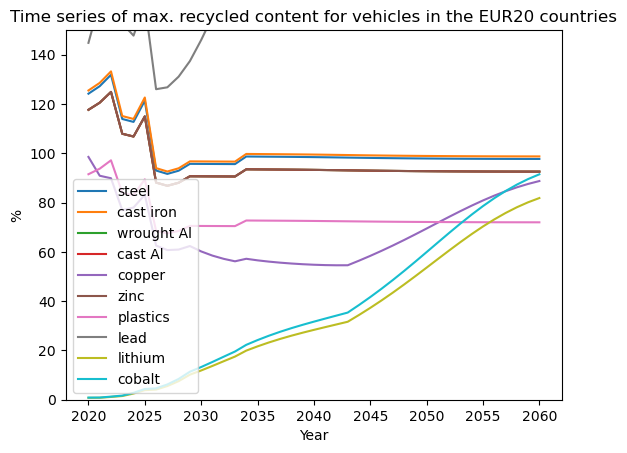

In [15]:
RC_new  = FRec[:,:,1] / I_tm * 100
# Note: EoL_RR comes with two scenarios. Here, we take the first one (current situation).
# Note: Unit converted to %.
# Note: Warnings are issued because the element-wise division of the two tables above leads to several x/0 or 0/0 values.

# The recycled content cannot be larger than 100%. If more secondary material is present, the excess material is exported to other sectors instead.
plt.plot(np.arange(2020,2061,1),RC_new[30::,:]) 
plt.title('Time series of max. recycled content for vehicles in the EUR20 countries')
plt.ylabel('%')
plt.xlabel('Year')
plt.gca().set_ylim(bottom=0) # set lower y boundary to 0
plt.gca().set_ylim(top=150) # set upper y boundary to 150 to see excess scrap supply in this sector.
plt.legend(['steel','cast iron','wrought Al','cast Al','copper','zinc','plastics','lead','lithium','cobalt'])
plt.savefig('Materials_Recycled_Content_New.png', dpi = 300) # save figure with the modifications made above.

As a consequence of the improved recycling rates (end-of-life recovery rates), the maximal recycled content is higher in this scenario. The values can be justified as follows:
- Steel and cast iron: large parts (body in white), can easily be recoverd and recycled
- Aluminium parts: smaller parts, higher remelting losses, maximum value a bit smaller than for steel
- Zinc: mostly used to cover steel for corrosion protection, improvements thus coupled to improvements for steel
- Copper: High value but dispersed use (cables, printed circuit boards)
- Plastics: Industry information that up to 70% recycled content are possible, rest must be primary plastics to keep quality high.
- Lead: the recycled content is very high already and soon, with the phase-out of internal combustion engine vehicles, there will be more lead supply in scrap from old cars than there is demand for lead in new cars. Since car batteries are the largest use of lead, there will likely be stockpiles of unused lead in the future.
- Lithium and Cobalt: With future recycling technologies, lithium and cobalt recycled content can increase to 70% after 2050, when there will be a steady supply of end-of-life BEVs.

### Task 5: Calculate the resulting primary material production FPrim!
The primary production simply is the mass balance of the manufacturing process in the system definition. It will be used to calculate the emissions of primary material production (scope 3) in the next workbook.

In [16]:
FPrim         = np.zeros((71,10,2))
FPrim[:,:,0]  = I_tm - FRec[:,:,0]
FPrim[:,:,0]  = I_tm - FRec[:,:,1]

# Note: because we have some reycling material flows that are larger than the required inflow, 
# some primary material production flows calculated here are negative.
# We correct for this by setting these flows to 0 instead and diverting the 
# excess secondary material to the export flow FEx instead.

FEx = np.zeros((71,10,2)) # Table for exporting excessive secondary material
for t in range(0,71): # for all years
    for m in range(0,10): # for all materials
        for s in range(0,2): # for all scenarios
            if FPrim[t,m,s]  < 0:
                FEx[t,m,s]   = -1 * FPrim[t,m,s].copy()
                FPrim[t,m,s] = 0                     

### Task 6: Export the material flows as Python pickle to hand them over to the GHG calculation in the next workbook!
This export concludes this exercise.

In [17]:
MatFlowResults = {'I_tm':I_tm, 'S_tm':S_tm, 'O_tm':O_tm, 'FRec': FRec, 'FPrim': FPrim} 

with open('Bath_dMFA_2026_Software_4_Results.pkl', 'wb') as f:  # open a text file
    pickle.dump(MatFlowResults, f) # serialize the list
f.close()  